In [7]:
import torch
import torch.nn as nn
from torchvision import transforms
from torchsummary import summary
from matplotlib import pyplot as plt
import numpy as np
from torch.nn import functional as F



In [8]:
import torch

# 1. 看看显卡能不能用了（必须是 True）
print(f"CUDA Available: {torch.cuda.is_available()}")

# 2. 看看版本号（必须带 +cu121）
print(f"Torch Version: {torch.__version__}")

# 3. 看看是哪张卡
if torch.cuda.is_available():
    print(f"Device Name: {torch.cuda.get_device_name(0)}")

CUDA Available: True
Torch Version: 2.5.1+cu121
Device Name: NVIDIA GeForce RTX 3050 Ti Laptop GPU


In [9]:
class AlexNet(nn.Module):
    def __init__(self):
        super(AlexNet,self).__init__()
        self.ReLu = nn.ReLU()
        self.c1 = nn.Conv2d(in_channels=3,out_channels=96,kernel_size=11,stride=4)
        self.s1 = nn.MaxPool2d(kernel_size=3,stride=2)
        self.c2 = nn.Conv2d(in_channels=96,out_channels=256,kernel_size=5,padding=2)
        self.s2 = nn.MaxPool2d(kernel_size=3,stride=2)
        self.c3 = nn.Conv2d(in_channels=256,out_channels=384,kernel_size=3,padding=1)
        self.c4 = nn.Conv2d(in_channels=384,out_channels=384,kernel_size=3,padding=1)
        self.c5 = nn.Conv2d(in_channels=384,out_channels=256,kernel_size=3,padding=1)
        self.s3 = nn.MaxPool2d(kernel_size=3,stride=2)
        self.flatten = nn.Flatten()
        self.l1 = nn.Linear(in_features=256*6*6,out_features=4096)#这里的input_features是上一个层的输出
        self.l2 = nn.Linear(in_features=4096,out_features=4096)
        self.l3 = nn.Linear(in_features=4096,out_features=10)
    def forward(self,x):
        x= self.c1(x)
        x= self.ReLu(x)
        x= self.s1(x)
        x= self.c2(x)
        x= self.ReLu(x)
        x= self.s2(x)
        x= self.c3(x)
        x= self.ReLu(x)
        x= self.c4(x)
        x = self.ReLu(x)
        x=self.c5(x)
        x= self.ReLu(x)
        x=self.s3(x)
        x= self.flatten(x)
        x= self.l1(x)
        x= self.ReLu(x)
        x =F.dropout(x,0.5)
        x = self.l2(x)
        x= self.ReLu(x)
        x =F.dropout(x,0.5)
        x =self.l3(x)
        return x
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AlexNet().to(device)
summary(model,(3,227,227))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 96, 55, 55]          34,944
              ReLU-2           [-1, 96, 55, 55]               0
         MaxPool2d-3           [-1, 96, 27, 27]               0
            Conv2d-4          [-1, 256, 27, 27]         614,656
              ReLU-5          [-1, 256, 27, 27]               0
         MaxPool2d-6          [-1, 256, 13, 13]               0
            Conv2d-7          [-1, 384, 13, 13]         885,120
              ReLU-8          [-1, 384, 13, 13]               0
            Conv2d-9          [-1, 384, 13, 13]       1,327,488
             ReLU-10          [-1, 384, 13, 13]               0
           Conv2d-11          [-1, 256, 13, 13]         884,992
             ReLU-12          [-1, 256, 13, 13]               0
        MaxPool2d-13            [-1, 256, 6, 6]               0
          Flatten-14                 [-

In [10]:
from torchvision.datasets import FashionMNIST
import torch.utils.data as Data
# 数据集构建
# 数据集构建
full_data = FashionMNIST(root='./data',train=True,transform=transforms.Compose([transforms.Resize(size=227),transforms.Grayscale(num_output_channels=3),transforms.ToTensor()]),download=True)
train_data,val_data = Data.random_split(dataset=full_data,lengths=[round(0.8*len(full_data)),round(0.2*len(full_data))])
train_loader = Data.DataLoader(dataset=train_data,batch_size=32,shuffle=True,num_workers=0)
val_loader = Data.DataLoader(dataset=val_data,batch_size=32,shuffle=False,num_workers=0)
# 获得一个batch的数据
i=1
for batch_idx,(data,target) in enumerate(train_loader):
    if i>0:
      print(data.shape)
      print(target.shape)
      i-=1
    if batch_idx > 0:
      break
    batch_x = data.squeeze().numpy()#将四维张亮去掉第一维
    batch_y=target.numpy()
    class_label = train_data.dataset.classes#训练集的类别标签
    # 打印数据形状
    print(f'batch_x.shape={batch_x.shape}')
    print(f'batch_y.shape={batch_y.shape}')
    print(class_label)


torch.Size([32, 3, 227, 227])
torch.Size([32])
batch_x.shape=(32, 3, 227, 227)
batch_y.shape=(32,)
['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


In [11]:
# 定义优化器和损失函数
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
optimizer = torch.optim.Adam(model.parameters(),lr=0.001)
criterion =nn.CrossEntropyLoss()#交叉熵用于分类


In [12]:
import pandas as pd
import copy
import torch
from torch.nn.modules import loss
from tqdm import tqdm
import time

# 训练
best_model_wts = copy.deepcopy(model.state_dict())
best_acc = 0.0
train_loss_all = []
val_loss_all = []
train_acc_all = []
val_acc_all = []
epoch_num = 20

for epoch in range(epoch_num):
    # 初始化每一轮的参数
    train_loss = 0.0
    train_acc = 0.0
    val_loss = 0.0
    val_acc = 0.0
    train_num = 0
    val_num = 0

    # =================  使用 tqdm 包裹 train_loader =================
    train_bar = tqdm(train_loader, desc=f'Epoch {epoch}/{epoch_num-1}', unit='batch')
    # 注意：这里循环的是 train_bar
    for step, (b_x, b_y) in enumerate(train_bar):
        b_x = b_x.to(device)
        b_y = b_y.to(device)
        model.train()
        optimizer.zero_grad()
        output = model(b_x)
        pre_label = torch.argmax(output, 1)
        loss = criterion(output, b_y)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * b_x.size(0)
        train_acc += torch.sum(pre_label == b_y.data)
        train_num += b_x.size(0)

        # =================  2: 实时更新进度条右侧的显示 =================
        # set_postfix 可以显示当前 Batch 的 Loss，让你知道模型是不是在收敛
        train_bar.set_postfix(loss=loss.item())

    # 验证阶段
    for step, (b_x, b_y) in enumerate(val_loader):
        b_x = b_x.to(device)
        b_y = b_y.to(device)
        model.eval()
        # 验证阶段记得加上 no_grad，省显存
        with torch.no_grad():
            output = model(b_x)
            pre_label = torch.argmax(output, 1)
            loss = criterion(output, b_y)
            val_loss += loss.item() * b_x.size(0)
            val_acc += torch.sum(pre_label == b_y.data)
            val_num += b_x.size(0)

    train_loss_all.append(train_loss / train_num)
    train_acc_all.append(train_acc.double() / train_num)
    val_loss_all.append(val_loss / val_num)
    val_acc_all.append(val_acc.double() / val_num)

    # 深度拷贝模型
    if val_acc_all[-1] > best_acc:
        best_acc = val_acc_all[-1]
        best_model_wts = copy.deepcopy(model.state_dict())


# 保存模型
torch.save(best_model_wts, 'best_model.pth')

# 数据转换处理
train_process = pd.DataFrame(data={
    "epoch": range(epoch_num),
    "train_loss": train_loss_all,
    "val_loss": val_loss_all,
    "train_acc": [x.cpu().item() if isinstance(x, torch.Tensor) else x for x in train_acc_all],
    "val_acc": [x.cpu().item() if isinstance(x, torch.Tensor) else x for x in val_acc_all]
})
print("Training Complete. Data saved.")

Epoch 19/19: 100%|██████████| 1500/1500 [03:44<00:00,  6.68batch/s, loss=0.367] 


Training Complete. Data saved.


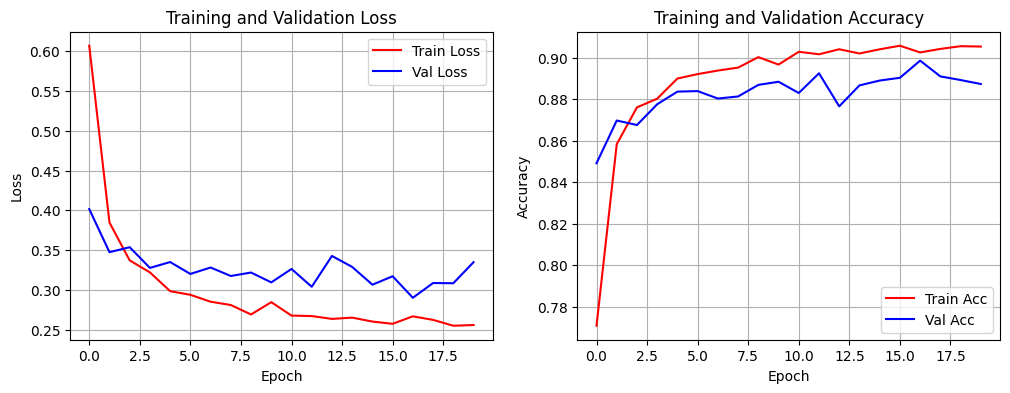

In [13]:
 # ==========================================
# 3. 开始画图 (Matplotlib)
# ==========================================
plt.figure(figsize=(12, 4)) # 设置画布大小：宽12，高4

# --- 第一张图：Loss (损失率) ---
plt.subplot(1, 2, 1) # 1行2列，第1张图
plt.plot(train_process['epoch'], train_process['train_loss'], 'r', label='Train Loss') # 红线
plt.plot(train_process['epoch'], train_process['val_loss'], 'b', label='Val Loss')   # 蓝线
plt.legend() # 显示图例
plt.grid(True) # 显示网格
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")

# --- 第二张图：Accuracy (准确率) ---
plt.subplot(1, 2, 2) # 1行2列，第2张图
plt.plot(train_process['epoch'], train_process['train_acc'], 'r', label='Train Acc')
plt.plot(train_process['epoch'], train_process['val_acc'], 'b', label='Val Acc')
plt.legend()
plt.grid(True)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")

# 显示图表
plt.show()
